# Decoding trial type from session sequences


In [1]:
prefix = '/home/ines/repositories/'
# prefix = '/Users/ineslaranjeira/Documents/Repositories/'

In [8]:
""" 
IMPORTS
"""
import os
import numpy as np
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# --Machine learning and statistics
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler,  LabelBinarizer
from sklearn.cluster import KMeans
import random
from sklearn import mixture
import pickle
from scipy.stats import mode
from sklearn.inspection import permutation_importance
import glob

# --Machine learning and statistics
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.preprocessing import OneHotEncoder
from scipy.stats import entropy

# Get my functions
# from functions import idxs_from_files, align_bin_design_matrix, states_per_trial_phase, broader_label, define_trial_types

from one.api import ONE
one = ONE(mode='remote')

In [4]:
def plot_cm(decoding_result, trial_epochs, size, control=False):
    """
    PLOT RESULTS
    """

    # -- Confusion Matrix
    # labels = trial_epochs

    # Results on original model
    plt.rc('font', size=8) 
    plt.figure(figsize=size)
    # hmap = sns.color_palette("mako", as_cmap=True)
    hmap=plt.cm.get_cmap('Greys')
    data = decoding_result.loc[decoding_result['shuffle'] == 0]
    sns.heatmap(data['confusion_matrix'].mean(), annot=False, square=True,
        yticklabels=trial_epochs, xticklabels=trial_epochs, 
        cmap= hmap, vmin=0, vmax=1, fmt=".2f") 

    # plt.xticks([.5, 1.5, 2.5, 3.5], trial_epochs)
    # plt.yticks([.5, 1.5, 2.5, 3.5], trial_epochs)
    plt.xticks(rotation = 90)
    plt.yticks(rotation = 0)
    plt.xlabel('Predicted trial type')
    plt.ylabel('True trial type')
    # plt.savefig('full_cm.svg',dpi=500)
    plt.show()
    print('F1 results', data['f1'].mean())

    if control:
        # Results from shuffled model
        plt.rc('font', size=9) 
        plt.figure(figsize=size)
        data = decoding_result.loc[decoding_result['shuffle'] >0]
        sns.heatmap(data['confusion_matrix'].mean(), annot=False, square=True,
            yticklabels=trial_epochs, xticklabels=trial_epochs, 
            cmap= hmap, vmin=0, vmax=1, fmt=".2f")

        # plt.xticks([.5, 1.5, 2.5, 3.5], trial_epochs)
        # plt.yticks([.5, 1.5, 2.5, 3.5], trial_epochs)
        plt.xticks(rotation = 90)
        plt.yticks(rotation = 0)
        plt.xlabel('Predicted mouse')
        plt.ylabel('True mouse')
        plt.show()
        print('F1 shuffled results',  data['f1'].mean())
    plt.tight_layout()

def plot_f1(decoding_result):
    # -- F1 score per model, original and shuffled
    data = decoding_result.copy()
    data['f1'] = data['f1'].astype(float)

    data.loc[data['shuffle'] >= 1, 'shuffle'] = 'Shuffled'
    data.loc[data['shuffle'] == 0, 'shuffle'] = 'Original'
    data = data.rename(columns={'shuffle': 'Dataset'})

    plt.rc('font', size=12) 
    plt.figure(figsize=[4.5, 4])
    sns.boxplot(y='f1', x='Dataset', data=data, color='grey') 
    sns.swarmplot(y='f1', x='Dataset', data=data, color='black', dodge=True, alpha=0.7, size=3)
    plt.ylim([0,1])
    plt.ylabel('Accuracy score (F1)')
    plt.legend(bbox_to_anchor=(1.05, 1))
    sns.despine(top=True, right=True)
    #plt.savefig('violin.svg',dpi=500)

In [53]:
group_cols = ['mouse_name', 'session', 'trial_id', 'correct', 'contrast', 'block', 'choice', 'broader_label']

In [54]:
save_states_path = prefix + 'representation_learning_variability/paper-individuality/data/states_files/'
# List existing files and extract mouse_name and sessions from filenames
states_files = glob.glob(os.path.join(save_states_path, "states_file_*"))

# Initialize container to collect pivoted results
all_pivoted_data = []

for states_file_path in states_files:
    # Extract filename without path
    filename = os.path.basename(states_file_path)
    filename_without_prefix = filename.replace("states_file_", "")
    session = filename_without_prefix[:36]
    mouse_name = filename_without_prefix[37:]  # Skip the underscore at position 36
    print(f"Processing: {mouse_name}, session: {session}")
    
    # Load states directly from file
    states = pd.read_parquet(states_file_path, engine='pyarrow').reset_index(drop=True)
    
    # Count syllables per group
    data = (states.groupby(group_cols + ['most_likely_states']).size().reset_index(name='count'))
    # Convert counts to fractions within each group
    data['usage'] = (data['count'] /data.groupby(group_cols)['count'].transform('sum'))
    
    
    # Append to collection
    all_pivoted_data.append(data)

# Combine all pivoted data into single DataFrame
combined_pivoted_data = pd.concat(all_pivoted_data, ignore_index=True)

print(f"Combined pivoted data shape: {combined_pivoted_data.shape}")

Processing: CSHL049, session: c99d53e6-c317-4c53-99ba-070b26673ac4
Processing: ibl_witten_32, session: 08102cfc-a040-4bcf-b63c-faa0f4914a6f
Processing: NYU-65, session: bb8d9451-fdbd-4f46-b52e-9290e8f84d2e
Processing: DY_011, session: cf43dbb1-6992-40ec-a5f9-e8e838d0f643
Processing: SWC_058, session: 3638d102-e8b6-4230-8742-e548cd87a949
Processing: ZFM-01935, session: ab8a0899-a59f-42e4-8807-95b14056104b
Processing: SWC_042, session: f9860a11-24d3-452e-ab95-39e199f20a93
Processing: CSHL047, session: 2d5f6d81-38c4-4bdc-ac3c-302ea4d5f46e
Processing: NR_0028, session: 5c0c560e-9e1f-45e9-b66e-e4ee7855be84
Processing: ZFM-01577, session: 63f3dbc1-1a5f-44e5-98dd-ce25cd2b7871
Processing: SWC_052, session: 7cb81727-2097-4b52-b480-c89867b5b34c
Processing: SWC_061, session: 360eac0c-7d2d-4cc1-9dcf-79fc7afc56e7
Processing: PL030, session: 283ecb4c-e529-409c-9f0a-8ea5191dcf50
Processing: SWC_053, session: 239cdbb1-68e2-4eb0-91d8-ae5ae4001c7a
Processing: NR_0020, session: 5b49aca6-a6f4-4075-931a-61

In [136]:
# Save data
data_path = prefix + 'representation_learning_variability/paper-individuality/2_pre-trial/'
filename = "syllable_prob.pqt"
combined_pivoted_data.to_parquet(data_path+filename)  

## Decode

In [ ]:
shufflings = 1  #shuffling
model = RandomForestClassifier(random_state=42)
# model = MultinomialNB()
repeats = 5

var = 'type'

In [48]:
def run_decoder(use_mat, model, shufflings, repeats, var):
    """
    RUN MODEL
    """

    # Generate random states for each iteration with a fixed seed
    # Loop over iterations of random draws of mice
    # Create empty dataframes to save results
    decoding_result = pd.DataFrame(columns=['shuffle', 'repeat', 'f1', 'confusion_matrix'])
    dec_result = pd.DataFrame(columns=['shuffle', 'repeat', 'f1', 'confusion_matrix'])

    # use_mat, named_labels = prepare_mat(df, final_matrix)

    for r in range(repeats):
        print('Repeat %d of %d' % (r+1, repeats))  
        # Decoding function with 10-fold cross validation
        kf = KFold(n_splits=5, shuffle=True, random_state=0)
        # use_mat = mat.copy() # test using all mice

        # Find minimum number of samples per label
        labels = np.array(use_mat[var])
        labels_nr = np.arange(len(use_mat[var]))
        min_freq = np.min(use_mat[var].value_counts())
        min_freq = 4000


        # Randomly select N mice from each quartile to equalize classes
        use_index = np.empty(0, dtype=int)
        for j, epoch in enumerate(np.unique(labels)):
            use_index = np.concatenate([use_index, np.random.choice(labels_nr[labels == epoch],
                                                                    min_freq, replace=False)])

        new_mat = use_mat.iloc[use_index].reset_index().drop(columns=['index']).copy()
                
        # -- ORIGINAL DATASET
        y_pred = np.zeros(len(new_mat), dtype=int) 
        exog = new_mat[new_mat.columns.difference([var])]
        endog = new_mat.loc[:, var].copy()

        for train_index, test_index in kf.split(new_mat):
            model.fit(exog.iloc[train_index], endog.iloc[train_index].astype(int))
            y_pred[test_index] = model.predict(exog.iloc[test_index])

        # Calculate f1 score and confusion matrix
        f1 = f1_score(endog.astype(int), y_pred.astype('int'), average='micro')
        cm = confusion_matrix(endog.astype(int), y_pred.astype('int'), normalize='true')

        # Save results
        dec_result.loc[0, 'f1'] = f1
        dec_result.loc[0, 'confusion_matrix'] = cm
        dec_result.loc[0, 'shuffle'] = 0
        dec_result.loc[0, 'repeat'] = r

        decoding_result = pd.concat([decoding_result, dec_result])

        # -- SHUFFLED DATASET 
        shuffle_result = pd.DataFrame(columns=['shuffle', 'f1', 'confusion_matrix'])
        for s in range(shufflings):
            if np.mod(s+1, 10) == 0:
                print('Shuffling %d of %d' % (s+1, shufflings))   

            shuffle_y_pred = np.zeros(len(new_mat), dtype=int) 
            shuffle_endog = endog.copy()
            np.random.shuffle(shuffle_endog.values)

            for train_index, test_index in kf.split(new_mat):
                model.fit(exog.iloc[train_index], list(shuffle_endog.iloc[train_index].astype(int)))
                shuffle_y_pred[test_index] = model.predict(exog.iloc[test_index])   

            shuffle_f1 = f1_score(shuffle_endog.astype(int), shuffle_y_pred.astype('int'), average='micro')
            shuffle_cm = confusion_matrix(shuffle_endog.astype(int), shuffle_y_pred.astype('int'), normalize='true')

            # SAVE
            shuffle_result.loc[s, 'f1'] = shuffle_f1
            shuffle_result.loc[s, 'confusion_matrix'] = shuffle_cm
            shuffle_result.loc[s, 'shuffle'] = s + 1

        decoding_result = pd.concat([decoding_result, shuffle_result])
    
    return decoding_result

In [80]:
all_results = pd.DataFrame(columns=['type', 'f1', 'cm', 'f1_shuffle', 'cm_shuffle'])

for t, typ in enumerate(['correct', 'contrast', 'block', 'choice']):
    
    design_df = combined_pivoted_data.pivot(index=['mouse_name', 'session', 'trial_id', 
                                                   typ], columns=['broader_label', 
                                                                  'most_likely_states'], values='usage').fillna(0).reset_index()
    
    use_mat = pd.DataFrame(np.array(design_df)[:, 4:].astype(float))
    use_mat['type'] = pd.factorize(design_df[typ])[0]
    named_labels = design_df[typ]

    decoding_result = run_decoder(use_mat, model, shufflings, repeats, var)
    # plot_cm(decoding_result, named_labels.drop_duplicates().dropna(), [4, 3], control=True)
    # plot_f1(decoding_result)

    result = pd.DataFrame(columns=['type', 'f1', 'cm', 'f1_shuffle', 'cm_shuffle'], index=range(repeats))
    result['type'] = typ
    result['f1'] = list(decoding_result.loc[decoding_result['shuffle']==0, 'f1'])
    result['cm'] = list(decoding_result.loc[decoding_result['shuffle']==0, 'confusion_matrix'])
    result['f1_shuffle'] = list(decoding_result.loc[decoding_result['shuffle']>0, 'f1'])
    result['cm_shuffle'] = list(decoding_result.loc[decoding_result['shuffle']>0, 'confusion_matrix'])

    # Save
    all_results = pd.concat([all_results, result])


Repeat 1 of 5
Repeat 2 of 5
Repeat 3 of 5
Repeat 4 of 5
Repeat 5 of 5


/tmp/ipykernel_23271/1435904605.py:25: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([all_results, result])


Repeat 1 of 5
Repeat 2 of 5
Repeat 3 of 5
Repeat 4 of 5
Repeat 5 of 5
Repeat 1 of 5
Repeat 2 of 5
Repeat 3 of 5
Repeat 4 of 5
Repeat 5 of 5
Repeat 1 of 5
Repeat 2 of 5
Repeat 3 of 5
Repeat 4 of 5
Repeat 5 of 5


/tmp/ipykernel_23271/2087902735.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  hmap = plt.cm.get_cmap('Greys')


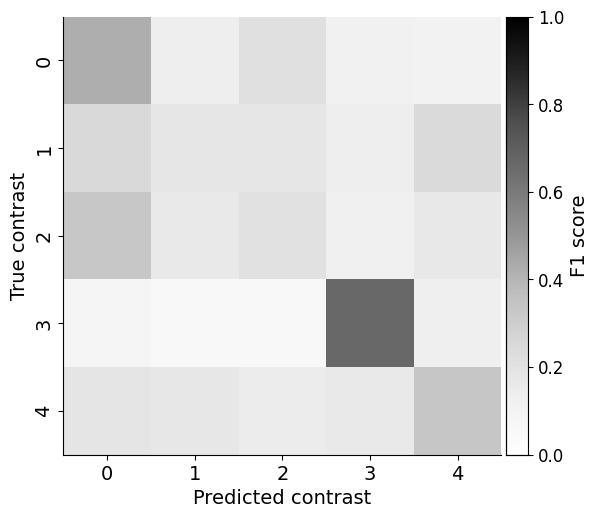

F1 results 0.36256


In [126]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=[6, 6])

divider = make_axes_locatable(ax)
plt.rc('font', size=8) 
hmap = plt.cm.get_cmap('Greys')
data = all_results.loc[all_results['type']=='contrast']

im = sns.heatmap(data['cm'].mean(), annot=False, square=True,
    cmap=hmap, vmin=0, vmax=1, fmt=".2f", ax=ax, cbar=False)  # Added cbar=False
    
cax = divider.append_axes('right', size='5%', pad=0.05)
mappable = ax.get_children()[0]
cbar = fig.colorbar(mappable, cax=cax, label='F1 score')
cbar.set_label('F1 score', fontsize=14)  # Label font size
cbar.ax.tick_params(labelsize=12)  # Tick label font size

im.set_xlabel('Predicted contrast')
im.set_ylabel('True contrast')
sns.despine(top=True, right=True)
# im.set_xticks([0.5, 1.5], ['Incorrect', 'Correct'], rotation=0)
# im.set_yticks([0.5, 1.5], ['Incorrect', 'Correct'], rotation=0)
plt.savefig(prefix + 'representation_learning_variability/paper-individuality/figures/' + 'cm_contrast.svg', format='svg', bbox_inches='tight')
plt.show()
print('F1 results', data['f1'].mean())

In [ ]:
# Save data
data_path = prefix + 'representation_learning_variability/paper-individuality/2_pre-trial/'
filename = "all_decoders_02042026"
all_results.to_pickle(data_path+filename)  

In [ ]:
trial_type_agg = ['correct', 'contrast', 'block', 'choice']

In [128]:
all_results['trial_type'] = all_results['type']
all_results.loc[all_results['type']==0, 'trial_type'] = 'Feedback'
all_results.loc[all_results['type']==1, 'trial_type'] = 'Contrast'
all_results.loc[all_results['type']==2, 'trial_type'] = 'Block'
all_results.loc[all_results['type']==3, 'trial_type'] = 'Choice'

In [129]:
pivot_decoders = pd.melt(all_results, id_vars=['trial_type'], value_vars=["f1", "f1_shuffle"])


/tmp/ipykernel_23271/1853274677.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='trial_type', y='value', hue='variable',


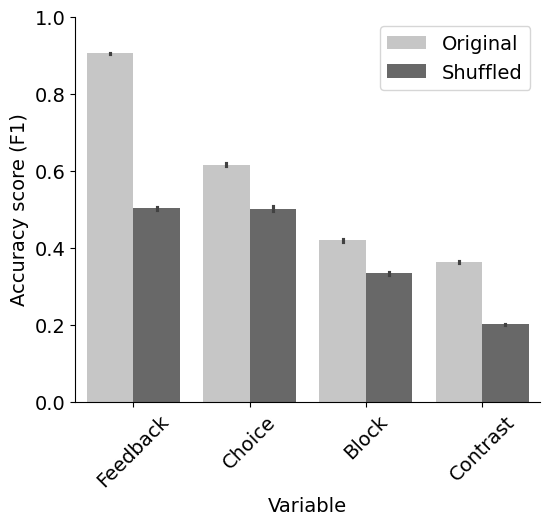

In [132]:

plt.rcParams.update({'font.size': 14})

plt.figure(figsize=[6, 5])
sns.barplot(x='trial_type', y='value', hue='variable',
                data=pivot_decoders, ci=95, palette='Greys', order=['correct','choice', 'block', 'contrast'])
plt.ylabel('Accuracy score (F1)', fontsize=14)
plt.xlabel('Variable', fontsize=14)
# sns.boxplot(y='f1', x='Dataset', data=data, color='grey') 
# sns.swarmplot(y='f1', x='Dataset', data=data, color='black', dodge=True, alpha=0.7, size=3)
plt.ylim([0, 1])
plt.xticks([0, 1, 2, 3], ['Feedback','Choice', 'Block', 'Contrast'], rotation=45)
handles, _ = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['Original', 'Shuffled'])
sns.despine(top=True, right=True)
plt.savefig(prefix + 'representation_learning_variability/paper-individuality/figures/' + 'fig2_trial_type_f1.svg', format='svg', bbox_inches='tight')



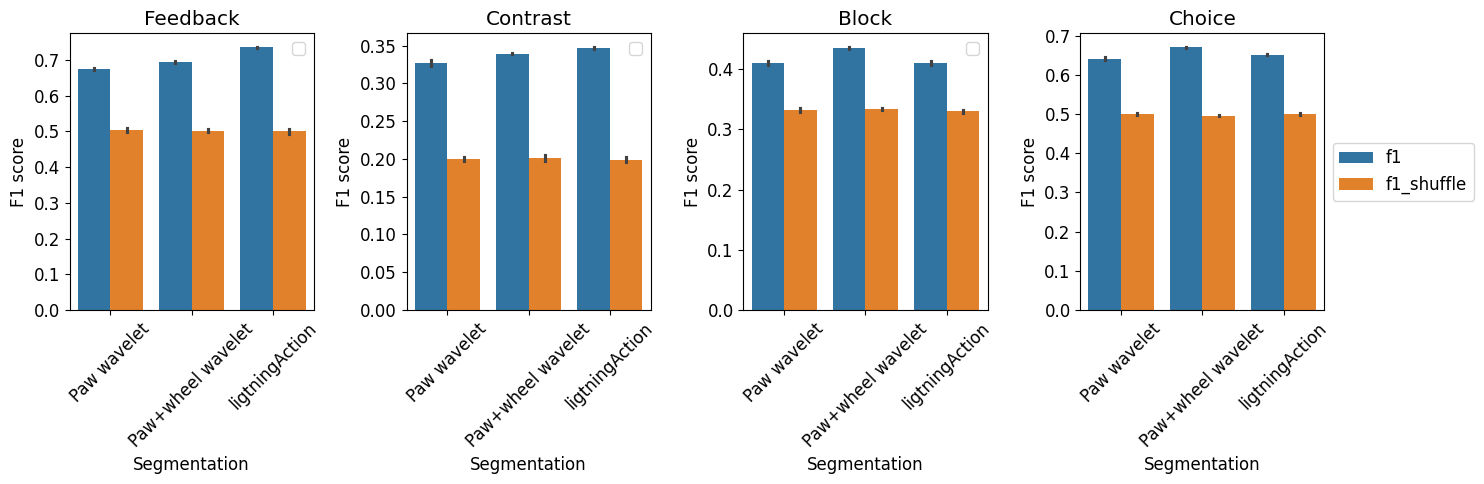

In [137]:
fig, ax = plt.subplots(ncols=4 , nrows=1, sharex=False, sharey=False, figsize=[15, 5])
for v, variable in enumerate(pivot_decoders.trial_type.unique()):
    sns.barplot(x='state', y='value', hue='variable', order = ['paw_states', 'most_likely_states', 'most_likely_action'],
                data=pivot_decoders.loc[pivot_decoders['trial_type']==variable], ax=ax[v])
    ax[v].set_ylabel('F1 score')
    ax[v].set_xlabel('Segmentation')
    ax[v].set_xticks([0, 1, 2], ['Paw wavelet', 'Paw+wheel wavelet', 'ligtningAction'], rotation=45)
    ax[v].legend('')
    
    # ax[v].set_ylim([np.min(pivot_decoders.loc[pivot_decoders['trial_type']==var, 'value'])-.1,
    #                 np.max(pivot_decoders.loc[pivot_decoders['trial_type']==var, 'value'])+.1])
    ax[v].set_title(variable)
plt.legend(loc = "center left", bbox_to_anchor = (1, 0.5))
plt.tight_layout()